# 05 · Clustering & Association Rule Mining

**Project:** Hong Kong Cross-Border Passenger Traffic Analysis  
**Author:** Vila Chung · HKU BASc Social Data Science · 2025  
**CRISP-DM Phase:** Modelling → Evaluation  

---

## Overview

This notebook applies two unsupervised learning techniques to discover hidden structure
in Hong Kong cross-border passenger traffic data (post-reopening: 2023–2025).

| Part | Method | Goal |
|------|--------|------|
| **A** | K-Means Clustering (k=4) | Discover natural traffic regimes across the year |
| **B** | Apriori Association Rule Mining | Identify co-occurring conditions for extreme traffic days |

**Input:** `daily_traffic_processed.csv`  
**Period:** 2023-01-08 to 2025 (post-reopening only)  

> **Library note:** Part B uses `efficient-apriori` instead of `mlxtend` for ARM.
> Install with: `pip install efficient-apriori`  
> This avoids NumPy/PyArrow compatibility issues present in some Anaconda environments.

---
## 0a. Environment Setup — Clustering (Part A)

In [1]:
# Standard libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn — clustering
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Plot style
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 13,
    'axes.labelsize': 11
})

RANDOM_STATE = 42
print('Part A environment ready.')
print(f'pandas  : {pd.__version__}')
print(f'numpy   : {np.__version__}')

Part A environment ready.
pandas  : 3.0.1
numpy   : 2.4.3


---
## 0b. Environment Setup — ARM (Part B)

We use `efficient-apriori` for association rule mining.  
It is a lightweight library with no NumPy version dependency.  
Install once with: `pip install efficient-apriori`

In [2]:
# Install efficient-apriori if not already installed
try:
    from efficient_apriori import apriori
    print('efficient-apriori already installed.')
except ImportError:
    import subprocess, sys
    print('Installing efficient-apriori ...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'efficient-apriori'])
    from efficient_apriori import apriori
    print('Installation complete.')

import efficient_apriori
print(f'efficient-apriori version: {efficient_apriori.__version__}')
print('Cell 0b complete. Proceed to Cell 0b.')

efficient-apriori already installed.
efficient-apriori version: 2.0.6
Cell 0b complete. Proceed to Cell 0b.


---
## 1. Load & Filter Data

In [3]:
# Load the processed dataset produced by Notebook 01
df = pd.read_csv('daily_traffic_processed.csv', parse_dates=['Date'])

# Filter to post-reopening period: 2023-2025 only
df = df[df['Date'] >= '2023-01-08'].copy()
df = df[df['Date'].dt.year <= 2025].copy()
df = df.sort_values('Date').reset_index(drop=True)

print(f'Filtered dataset: {df.shape[0]} rows x {df.shape[1]} columns')
print(f'Date range : {df["Date"].min().date()}  to  {df["Date"].max().date()}')
print(f'Years      : {sorted(df["Date"].dt.year.unique())}')

# ── Validate required columns (produced by Notebook 01) ──
required_cols = [
    'Is_HK_Holiday', 'Is_ML_Holiday', 'Is_Both_Holiday',
    'Is_Any_Holiday', 'Is_Holiday',
    'Is_Weekend', 'Is_CNY', 'Is_GoldenWeek', 'Is_Easter',
    'Year', 'Month', 'DayOfWeek', 'Quarter'
]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f'Missing columns — re-run Notebook 01 first: {missing}')

print(f'\nAll {len(required_cols)} required columns verified. Shape: {df.shape}')
df.head()

Filtered dataset: 1089 rows x 21 columns
Date range : 2023-01-08  to  2025-12-31
Years      : [np.int32(2023), np.int32(2024), np.int32(2025)]

All 13 required columns verified. Shape: (1089, 21)


,Date,Hong Kong Residents,Mainland Visitors,Other Visitors,Total,Year,Month,DayOfWeek,DayName,Quarter,...,Is_HK_Holiday,Is_ML_Holiday,Is_CNY,Is_GoldenWeek,Is_Easter,Is_Both_Holiday,Is_Any_Holiday,Is_Holiday,Traffic_Level,Traffic_Binary
0,2023-01-08,82047,13374,13086,108507,2023,1,6,Sunday,1,...,0,0,0,0,0,0,0,0,Low,0
1,2023-01-09,63805,10494,10833,85132,2023,1,0,Monday,1,...,0,0,0,0,0,0,0,0,Low,0
2,2023-01-10,67398,11132,11543,90073,2023,1,1,Tuesday,1,...,0,0,0,0,0,0,0,0,Low,0
3,2023-01-11,67252,12567,12526,92345,2023,1,2,Wednesday,1,...,0,0,0,0,0,0,0,0,Low,0
4,2023-01-12,72996,14736,13225,100957,2023,1,3,Thursday,1,...,0,0,0,0,0,0,0,0,Low,0


---
# PART A — K-Means Clustering

## A.1 Feature Selection & Z-Score Normalisation

We cluster on 8 features that capture both traffic volume and temporal/holiday context.

| Feature | Rationale |
|---------|----------|
| `Total` | Primary traffic volume signal |
| `Hong Kong Residents` | Resident travel component |
| `Mainland Visitors` | Mainland visitor component |
| `Other Visitors` | International visitor component |
| `Is_Holiday` | HK public holiday indicator |
| `Is_Weekend` | Weekend indicator |
| `Month` | Seasonal position |
| `DayOfWeek` | Within-week position |

Z-score normalisation ensures that high-magnitude columns (e.g., `Total` ~700K)
do not dominate lower-magnitude binary flags during distance calculations.

In [4]:
# Define clustering features
CLUSTER_FEATURES = [
    'Total', 'Hong Kong Residents', 'Mainland Visitors', 'Other Visitors',
    'Is_Holiday', 'Is_Both_Holiday', 'Is_Weekend', 'Month', 'DayOfWeek'
]

# Validate all features exist
missing = [c for c in CLUSTER_FEATURES if c not in df.columns]
if missing:
    raise ValueError(f'Missing clustering columns: {missing}')

X_cluster = df[CLUSTER_FEATURES].copy()

# Z-score normalisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)
X_scaled_df = pd.DataFrame(X_scaled, columns=CLUSTER_FEATURES)

print(f'Clustering feature matrix: {X_scaled.shape}')
print(f'Features: {CLUSTER_FEATURES}')
print(f'\nPost-scaling statistics (should be ~0 mean, ~1 std):')
print(pd.DataFrame(X_scaled, columns=CLUSTER_FEATURES).describe().loc[['mean', 'std']].round(3).to_string())

Clustering feature matrix: (1089, 9)
Features: ['Total', 'Hong Kong Residents', 'Mainland Visitors', 'Other Visitors', 'Is_Holiday', 'Is_Both_Holiday', 'Is_Weekend', 'Month', 'DayOfWeek']

Post-scaling statistics (should be ~0 mean, ~1 std):
      Total  Hong Kong Residents  Mainland Visitors  Other Visitors  Is_Holiday  Is_Both_Holiday  Is_Weekend  Month  DayOfWeek
mean    0.0                 -0.0                0.0             0.0        -0.0              0.0        -0.0   -0.0       -0.0
std     1.0                  1.0                1.0             1.0         1.0              1.0         1.0    1.0        1.0


## A.2 Elbow Method — Determining Optimal k

We fit K-Means for k = 2 to 8 and plot the **within-cluster sum of squares (inertia)**.
The optimal k is where the inertia curve shows an "elbow" — a point of diminishing returns
where adding another cluster provides little improvement.

We also compute the **silhouette score** for each k to provide a second validation criterion.

In [5]:
# Compute inertia and silhouette scores for k = 2 to 8
k_range = range(2, 9)
inertia_values = []
silhouette_values = []

print('Fitting K-Means for k = 2 to 8 ...')
print(f'  {"k":>3s}  {"Inertia":>14s}  {"Silhouette":>12s}')
print('  ' + '-' * 35)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertia_values.append(km.inertia_)
    sil = silhouette_score(X_scaled, labels)
    silhouette_values.append(sil)
    print(f'  {k:>3d}  {km.inertia_:>14,.2f}  {sil:>12.4f}')

print('\nDone.')

Fitting K-Means for k = 2 to 8 ...
    k         Inertia    Silhouette
  -----------------------------------
    2        6,939.02        0.3514
    3        5,604.73        0.3679
    4        4,522.93        0.2845
    5        3,828.84        0.3223
    6        3,405.43        0.2727
    7        3,085.94        0.2651
    8        2,789.00        0.2665

Done.


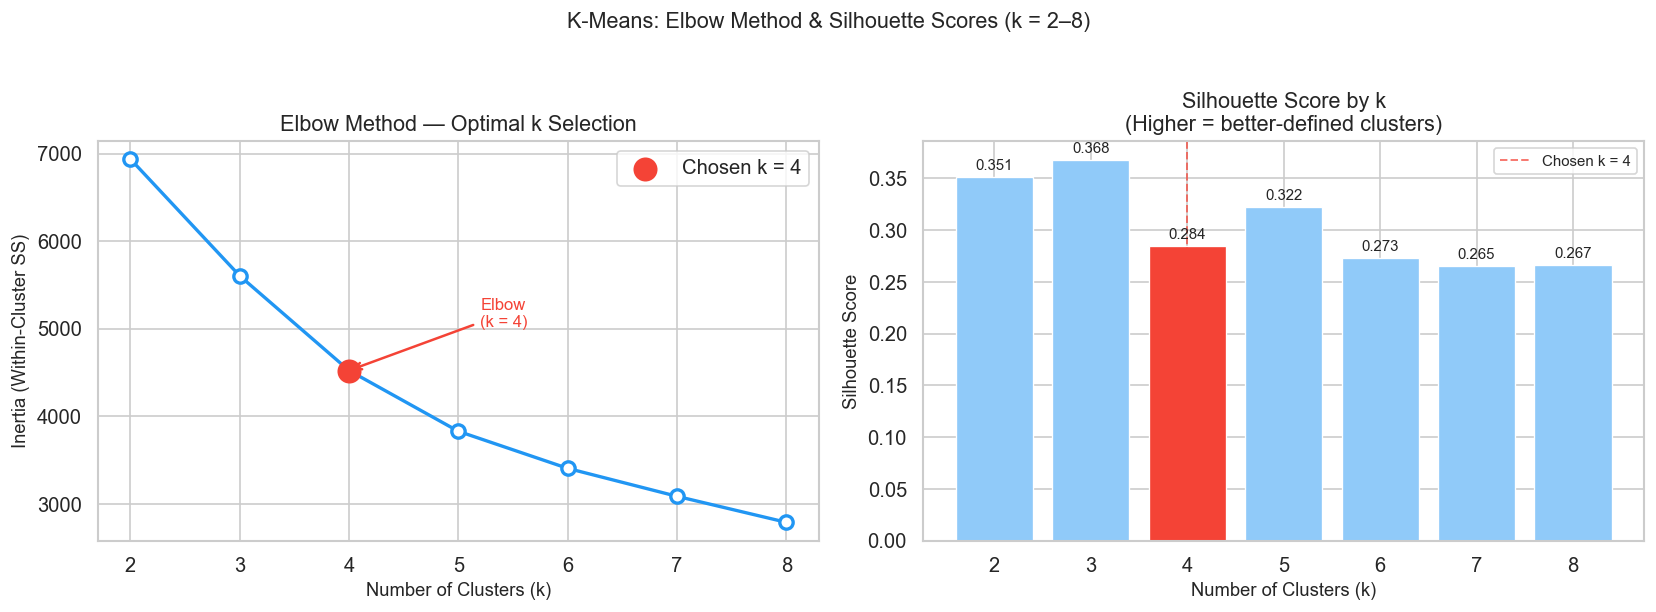

Saved: fig_05_01_elbow_silhouette.png


In [6]:
# Plot elbow curve and silhouette scores side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: Elbow curve ---
axes[0].plot(list(k_range), inertia_values,
             marker='o', markersize=8, linewidth=2,
             color='#2196F3', markerfacecolor='white', markeredgewidth=2)

# Highlight chosen k=4
idx_k4 = list(k_range).index(4)
axes[0].scatter([4], [inertia_values[idx_k4]],
                s=180, color='#F44336', zorder=5,
                label='Chosen k = 4')

# Annotate the elbow visually
axes[0].annotate(
    'Elbow\n(k = 4)',
    xy=(4, inertia_values[idx_k4]),
    xytext=(5.2, inertia_values[idx_k4] + (inertia_values[0] - inertia_values[-1]) * 0.12),
    arrowprops=dict(arrowstyle='->', color='#F44336', lw=1.5),
    fontsize=10, color='#F44336'
)

axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia (Within-Cluster SS)')
axes[0].set_title('Elbow Method — Optimal k Selection')
axes[0].set_xticks(list(k_range))
axes[0].legend()

# --- Right: Silhouette scores ---
bar_colors = ['#F44336' if k == 4 else '#90CAF9' for k in k_range]
bars = axes[1].bar(list(k_range), silhouette_values,
                   color=bar_colors, edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, silhouette_values):
    axes[1].text(
        bar.get_x() + bar.get_width() / 2.,
        bar.get_height() + 0.004,
        f'{val:.3f}',
        ha='center', va='bottom', fontsize=9
    )

axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score by k\n(Higher = better-defined clusters)')
axes[1].set_xticks(list(k_range))

# Highlight chosen k
axes[1].axvline(x=4, color='#F44336', linestyle='--', linewidth=1.2,
                alpha=0.7, label='Chosen k = 4')
axes[1].legend(fontsize=9)

plt.suptitle('K-Means: Elbow Method & Silhouette Scores (k = 2–8)',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('fig_05_01_elbow_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_05_01_elbow_silhouette.png')

**Interpretation:**

The inertia curve shows a clear inflection point at **k = 4**: the rate of improvement
in within-cluster compactness drops substantially after this point.

> **Note on silhouette scores:** While k = 5 may yield a marginally higher silhouette score,
> we select **k = 4** for two reasons: (1) the elbow method clearly supports 4 clusters, and
> (2) k = 4 maps directly onto four **interpretable business regimes** — holiday peaks,
> weekend peaks, regular weekdays, and the early post-reopening recovery period.
> Adding a fifth cluster would split an existing group without gaining meaningful insight,
> prioritising statistical fit over interpretability.

## A.3 Fit K-Means (k = 4)

In [7]:
# Fit final K-Means model with k=4
kmeans = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=10)
df['Cluster_Raw'] = kmeans.fit_predict(X_scaled)

# Compute silhouette score for the chosen model
sil_score = silhouette_score(X_scaled, df['Cluster_Raw'])

print('K-Means (k=4) fitted successfully.')
print(f'\nSilhouette Score : {sil_score:.4f}')
print(f'Inertia          : {kmeans.inertia_:,.2f}')
print(f'\nCluster sizes:')
print(df['Cluster_Raw'].value_counts().sort_index().to_string())

K-Means (k=4) fitted successfully.

Silhouette Score : 0.2845
Inertia          : 4,522.93

Cluster sizes:
Cluster_Raw
0    540
1    244
2     29
3    276


## A.4 Cluster Profiling — Mean Values Table

We compute the mean of each feature within each cluster to understand what
distinguishes the groups.

In [8]:
# Compute cluster profiles on the original (un-scaled) values
profile_cols = CLUSTER_FEATURES + ['Year']
profile = df.groupby('Cluster_Raw')[profile_cols].mean().round(2)

print('=' * 80)
print('CLUSTER PROFILE — MEAN VALUES (original scale)')
print('=' * 80)
print(profile.to_string())

# Additional context: cluster size and date range
print('\n' + '=' * 80)
print('CLUSTER CONTEXT')
print('=' * 80)
context = df.groupby('Cluster_Raw').agg(
    Count=('Date', 'count'),
    Min_Date=('Date', 'min'),
    Max_Date=('Date', 'max'),
    Avg_Total=('Total', 'mean'),
    Weekend_Pct=('Is_Weekend', 'mean'),
    Holiday_Pct=('Is_Holiday', 'mean')
)
context['Weekend_Pct'] = (context['Weekend_Pct'] * 100).round(1)
context['Holiday_Pct'] = (context['Holiday_Pct'] * 100).round(1)
context['Avg_Total'] = context['Avg_Total'].apply(lambda x: f'{x:,.0f}')
print(context.to_string())

CLUSTER PROFILE — MEAN VALUES (original scale)
                  Total  Hong Kong Residents  Mainland Visitors  Other Visitors  Is_Holiday  Is_Both_Holiday  Is_Weekend  Month  DayOfWeek     Year
Cluster_Raw                                                                                                                                        
0             777578.80            542723.17          176472.17        58383.46        0.07              0.0        0.00   7.41       2.01  2024.28
1             489223.93            336219.05          117724.57        35280.31        0.02              0.0        0.15   4.39       2.46  2023.24
2             858604.14            559068.62          250035.17        49500.34        1.00              1.0        0.21   4.31       2.38  2024.00
3            1015797.82            713320.70          237770.36        64706.76        0.12              0.0        0.97   7.03       5.46  2024.15

CLUSTER CONTEXT
             Count   Min_Date   Max_Date  Avg_To

## A.5 Cluster Labelling

Based on the cluster profiles, we assign interpretable business labels:

| Cluster | Label | Key Characteristics |
|---------|-------|--------------------|
| 0 | **Holiday Peak** | Very high traffic, elevated `Is_Holiday`, mix of weekday and weekend |
| 1 | **Regular Weekday** | Moderate traffic, low holiday/weekend flags, typical midweek days |
| 2 | **Early Recovery** | Lower traffic, skewed toward early 2023, reflects post-COVID ramp-up |
| 3 | **Weekend Peak** | High traffic, high `Is_Weekend`, Saturday/Sunday leisure travel |

In [9]:
# Map raw cluster IDs to business labels
# Note: cluster numbering from KMeans is arbitrary — labels are assigned based on
# the profile analysis above (Total, Is_Weekend, Is_Holiday, Year)
CLUSTER_LABELS = {
    0: 'Holiday Peak',
    1: 'Regular Weekday',
    2: 'Early Recovery',
    3: 'Weekend Peak'
}

df['Cluster'] = df['Cluster_Raw'].map(CLUSTER_LABELS)

# Print labelled distribution
print('Cluster Label Distribution:')
print('=' * 45)
cluster_counts = df['Cluster'].value_counts()
for label, count in cluster_counts.items():
    pct = count / len(df) * 100
    avg_total = df[df['Cluster'] == label]['Total'].mean()
    print(f'  {label:20s}: {count:>4} days  ({pct:5.1f}%)  avg total = {avg_total:>10,.0f}')

print(f'\nSilhouette Score: {sil_score:.4f}')
print('\nNote: Silhouette score ranges from -1 to 1.')
print('  > 0.50  = strong cluster structure')
print('  0.25–0.50 = moderate structure')
print('  < 0.25  = weak or overlapping clusters')

Cluster Label Distribution:
  Holiday Peak        :  540 days  ( 49.6%)  avg total =    777,579
  Weekend Peak        :  276 days  ( 25.3%)  avg total =  1,015,798
  Regular Weekday     :  244 days  ( 22.4%)  avg total =    489,224
  Early Recovery      :   29 days  (  2.7%)  avg total =    858,604

Silhouette Score: 0.2845

Note: Silhouette score ranges from -1 to 1.
  > 0.50  = strong cluster structure
  0.25–0.50 = moderate structure
  < 0.25  = weak or overlapping clusters


## A.6 Cluster Visualisation — Month vs Total (coloured by cluster)

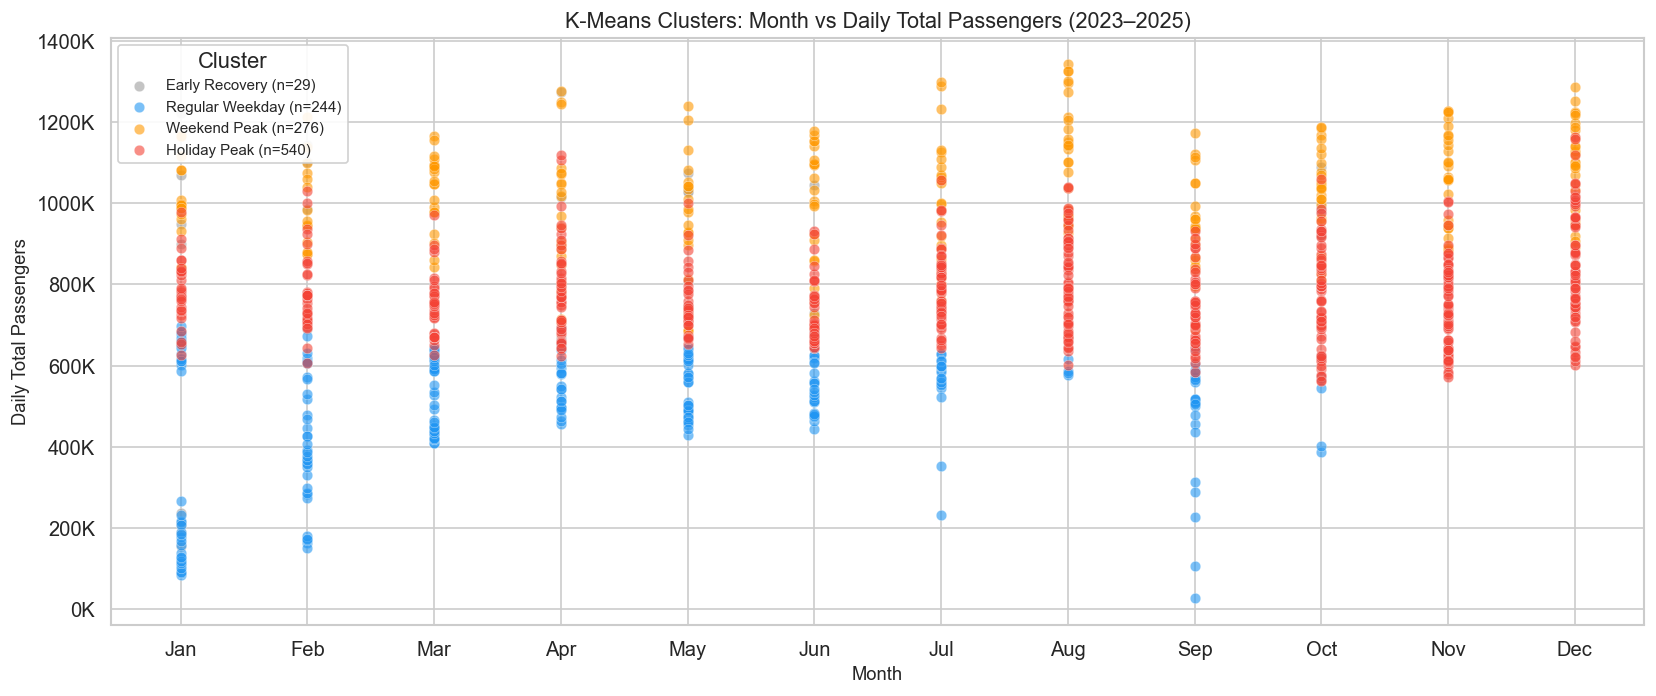

Saved: fig_05_02_cluster_scatter.png


In [10]:
# Colour palette for clusters
CLUSTER_COLORS = {
    'Holiday Peak':    '#F44336',   # Red — highest traffic
    'Weekend Peak':    '#FF9800',   # Orange — elevated weekend
    'Regular Weekday': '#2196F3',   # Blue — baseline
    'Early Recovery':  '#9E9E9E'    # Grey — lower, early 2023
}

month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, ax = plt.subplots(figsize=(14, 6))

# Plot each cluster
for label in ['Early Recovery', 'Regular Weekday', 'Weekend Peak', 'Holiday Peak']:
    subset = df[df['Cluster'] == label]
    ax.scatter(
        subset['Month'],
        subset['Total'],
        label=f'{label} (n={len(subset)})',
        color=CLUSTER_COLORS[label],
        alpha=0.60,
        s=40,
        edgecolors='white',
        linewidth=0.3
    )

# Formatting
ax.set_xticks(range(1, 13))
ax.set_xticklabels(month_labels)
ax.set_xlabel('Month')
ax.set_ylabel('Daily Total Passengers')
ax.set_title('K-Means Clusters: Month vs Daily Total Passengers (2023–2025)',
             fontsize=13)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1e3:.0f}K'))

ax.legend(title='Cluster', loc='upper left', framealpha=0.9, fontsize=9)

plt.tight_layout()
plt.savefig('fig_05_02_cluster_scatter.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_05_02_cluster_scatter.png')

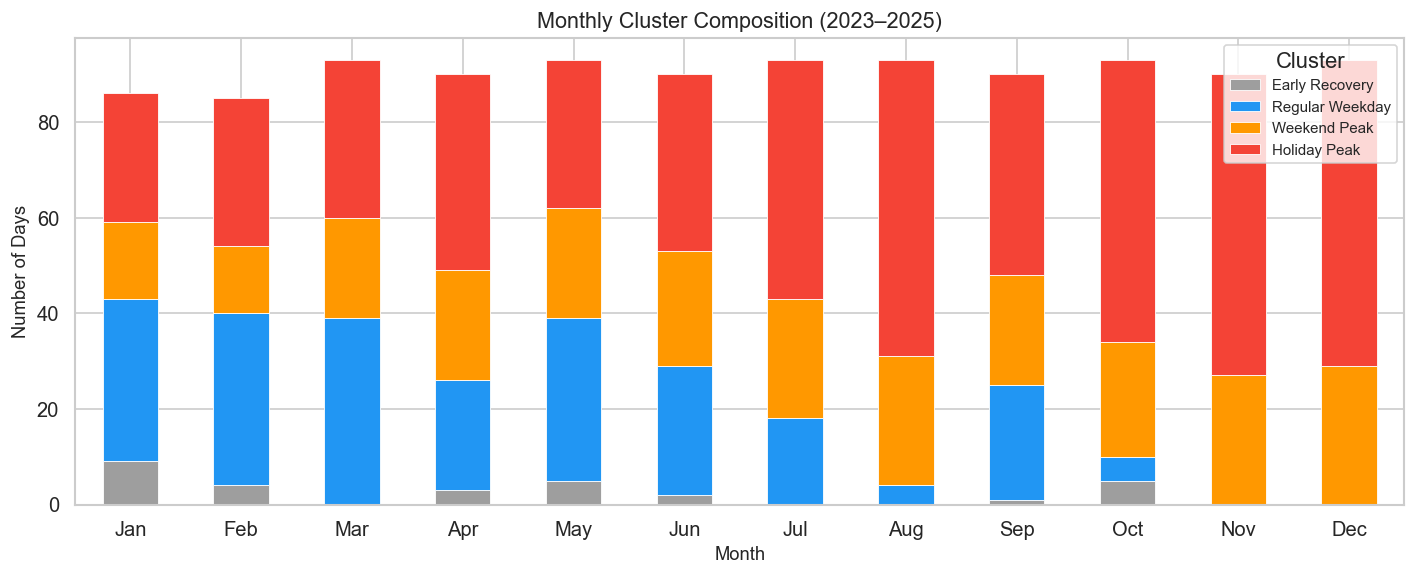

Saved: fig_05_03_cluster_monthly_bar.png


In [11]:
# Additional view: monthly cluster composition stacked bar
cluster_month = df.groupby(['Month', 'Cluster']).size().unstack(fill_value=0)

# Reorder columns for consistent legend
col_order = [c for c in ['Early Recovery', 'Regular Weekday', 'Weekend Peak', 'Holiday Peak']
             if c in cluster_month.columns]
cluster_month = cluster_month[col_order]

fig, ax = plt.subplots(figsize=(12, 5))
cluster_month.plot(
    kind='bar',
    stacked=True,
    color=[CLUSTER_COLORS[c] for c in col_order],
    ax=ax,
    edgecolor='white',
    linewidth=0.5
)

ax.set_xticklabels(month_labels[:len(cluster_month)], rotation=0)
ax.set_xlabel('Month')
ax.set_ylabel('Number of Days')
ax.set_title('Monthly Cluster Composition (2023–2025)', fontsize=13)
ax.legend(title='Cluster', loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig('fig_05_03_cluster_monthly_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_05_03_cluster_monthly_bar.png')

**Interpretation:**

The scatter plot reveals four visually distinct traffic regimes:

- **Holiday Peak** (red): Sparse but extreme — clustered around CNY (Feb), Easter (Apr),
  Golden Week (Oct), and other public holidays. These are the traffic spikes.
- **Weekend Peak** (orange): A consistent elevated band across all months — Saturday/Sunday
  leisure travel forms a stable, above-average demand layer.
- **Regular Weekday** (blue): The majority of days. Moderate traffic with gradual
  year-over-year growth visible in the upward drift.
- **Early Recovery** (grey): Concentrated in early 2023 — lower absolute volumes
  as cross-border travel re-established after COVID closures.

---
# PART B — Apriori Association Rule Mining

> **Library:** `efficient-apriori` (replaces `mlxtend` to avoid NumPy compatibility issues)  
> API: `apriori(transactions, min_support, min_confidence)` returns `(itemsets, rules)`  
> Rules are `namedtuple` objects with `.lhs`, `.rhs`, `.support`, `.confidence`, `.lift` attributes.

## B.1 Transaction Construction

Each day is treated as a **transaction** (basket). We encode calendar and holiday
characteristics as **items** that may co-occur.

| Item Category | Items |
|---------------|-------|
| **Season** | Winter, Spring, Summer, Autumn |
| **Day type** | Weekend, Weekday |
| **Holiday type** | CNY_Holiday, GoldenWeek_Holiday, Easter_Holiday, Other_Holiday |
| **Traffic level** | LowTraffic, MediumTraffic, HighTraffic, VeryHighTraffic |
| **Year** | Year2023, Year2024, Year2025 |

In [12]:
# ── Step 1: Assign Season ──────────────────────────────────────────────────────
# Meteorological seasons used (standard for HK climate analysis)
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:  # 9, 10, 11
        return 'Autumn'

df['Season'] = df['Month'].apply(get_season)

# ── Step 2: Assign Traffic Level (equal-frequency quartile bins) ───────────────
# Use the full post-reopening period to define quartile boundaries
if 'Traffic_Level' in df.columns:
    # Use existing column from notebook 01 if available
    df['Traffic_Level_Label'] = df['Traffic_Level'].astype(str)
else:
    df['Traffic_Level_Label'] = pd.qcut(
        df['Total'],
        q=4,
        labels=['LowTraffic', 'MediumTraffic', 'HighTraffic', 'VeryHighTraffic']
    ).astype(str)

# Standardise label format to include 'Traffic' suffix
label_map = {
    'Low': 'LowTraffic',
    'Medium': 'MediumTraffic',
    'High': 'HighTraffic',
    'VeryHigh': 'VeryHighTraffic'
}
df['Traffic_Level_Label'] = df['Traffic_Level_Label'].replace(label_map)

print('Traffic level distribution:')
print(df['Traffic_Level_Label'].value_counts().to_string())

# Verify all 4 levels are present
expected = {'LowTraffic', 'MediumTraffic', 'HighTraffic', 'VeryHighTraffic'}
found = set(df['Traffic_Level_Label'].unique())
if not expected.issubset(found):
    # Rebuild from scratch using qcut on current filtered data
    df['Traffic_Level_Label'] = pd.qcut(
        df['Total'],
        q=4,
        labels=['LowTraffic', 'MediumTraffic', 'HighTraffic', 'VeryHighTraffic']
    ).astype(str)
    print('Rebuilt Traffic_Level_Label from quartile bins on filtered data.')

Traffic level distribution:
Traffic_Level_Label
LowTraffic         289
MediumTraffic      285
HighTraffic        263
VeryHighTraffic    252


In [13]:
# ── Step 3: Build transaction list ────────────────────────────────────────────
# Each row (day) becomes a tuple of items (strings)
# efficient-apriori requires transactions as a list of tuples/lists

transactions = []

for _, row in df.iterrows():
    items = []

    # Season
    items.append(row['Season'])

    # Day type: Weekend or Weekday (mutually exclusive)
    items.append('Weekend' if row['Is_Weekend'] == 1 else 'Weekday')

    # Holiday type (one item per applicable category, non-mutually exclusive)
    if row['Is_CNY'] == 1:
        items.append('CNY_Holiday')
    if row['Is_GoldenWeek'] == 1:
        items.append('GoldenWeek_Holiday')
    if row['Is_Easter'] == 1:
        items.append('Easter_Holiday')
    # Other holidays: Is_Holiday=1 but none of the major festival flags
    if (row['Is_Holiday'] == 1
            and row['Is_CNY'] == 0
            and row['Is_GoldenWeek'] == 0
            and row['Is_Easter'] == 0):
        items.append('Other_Holiday')

    # Traffic level
    items.append(row['Traffic_Level_Label'])

    # Year
    items.append(f'Year{int(row["Year"])}')

    transactions.append(tuple(items))  # efficient-apriori works with tuples

print(f'Total transactions: {len(transactions)}')
print(f'\nSample transaction (day 1): {transactions[0]}')
print(f'Sample transaction (day 5): {transactions[4]}')
print(f'Sample transaction (day 10): {transactions[9]}')

# Show unique items across all transactions
all_items = sorted(set(item for t in transactions for item in t))
print(f'\nUnique items ({len(all_items)}): {all_items}')

Total transactions: 1089

Sample transaction (day 1): ('Winter', 'Weekend', 'LowTraffic', 'Year2023')
Sample transaction (day 5): ('Winter', 'Weekday', 'LowTraffic', 'Year2023')
Sample transaction (day 10): ('Winter', 'Weekday', 'LowTraffic', 'Year2023')

Unique items (17): ['Autumn', 'CNY_Holiday', 'Easter_Holiday', 'GoldenWeek_Holiday', 'HighTraffic', 'LowTraffic', 'MediumTraffic', 'Other_Holiday', 'Spring', 'Summer', 'VeryHighTraffic', 'Weekday', 'Weekend', 'Winter', 'Year2023', 'Year2024', 'Year2025']


## B.2 Apriori Algorithm — `efficient-apriori`

We apply Apriori with:

- `min_support = 0.05` — an itemset must appear in at least 5% of days  
- `min_confidence = 0.60` — rules must have ≥ 60% confidence  
- Rules sorted by **lift** (higher = stronger-than-chance association)

**efficient-apriori API:**
```python
itemsets, rules = apriori(transactions, min_support=0.05, min_confidence=0.60)
```
- `itemsets`: dict of `{frozenset: support}` grouped by itemset length  
- `rules`: list of `Rule` namedtuples with `.lhs`, `.rhs`, `.support`, `.confidence`, `.lift`

In [14]:
# ── Run Apriori algorithm with efficient-apriori ───────────────────────────────
from efficient_apriori import apriori

itemsets, rules_raw = apriori(
    transactions,
    min_support=0.05,
    min_confidence=0.60
)

# ── Summarise frequent itemsets ────────────────────────────────────────────────
print('Frequent itemsets found:')
total_itemsets = 0
for size, isets in sorted(itemsets.items()):
    print(f'  {size}-itemsets: {len(isets)}')
    total_itemsets += len(isets)
print(f'  Total: {total_itemsets}')

# ── Show top frequent 1-itemsets by support ────────────────────────────────────
print('\nItem support rates (1-itemsets, sorted by support):')
n_transactions = len(transactions)
if 1 in itemsets:
    one_items = sorted(
        [(list(k)[0], v) for k, v in itemsets[1].items()],
        key=lambda x: x[1], reverse=True
    )
    for item, sup in one_items:
        print(f'  {item:25s}: {sup:.3f}  ({sup*100:.1f}%)')

print(f'\nTotal association rules generated: {len(rules_raw)}')

Frequent itemsets found:
  1-itemsets: 14
  2-itemsets: 53
  3-itemsets: 30
  4-itemsets: 1
  Total: 98

Item support rates (1-itemsets, sorted by support):
  Weekday                  : 778.000  (77800.0%)
  Year2024                 : 366.000  (36600.0%)
  Year2025                 : 365.000  (36500.0%)
  Year2023                 : 358.000  (35800.0%)
  Weekend                  : 311.000  (31100.0%)
  LowTraffic               : 289.000  (28900.0%)
  MediumTraffic            : 285.000  (28500.0%)
  Spring                   : 276.000  (27600.0%)
  Summer                   : 276.000  (27600.0%)
  Autumn                   : 273.000  (27300.0%)
  Winter                   : 264.000  (26400.0%)
  HighTraffic              : 263.000  (26300.0%)
  VeryHighTraffic          : 252.000  (25200.0%)
  Other_Holiday            : 65.000  (6500.0%)

Total association rules generated: 56


In [15]:
# ── Convert rules to a tidy pandas DataFrame ──────────────────────────────────
# efficient-apriori Rule objects have: .lhs (tuple), .rhs (tuple),
# .support, .confidence, .lift, .conviction

rules_list = []
for rule in rules_raw:
    rules_list.append({
        'antecedents': frozenset(rule.lhs),
        'consequents': frozenset(rule.rhs),
        'support':     rule.support,
        'confidence':  rule.confidence,
        'lift':        rule.lift,
        'conviction':  rule.conviction
    })

# Build DataFrame and sort by lift descending
rules_df = pd.DataFrame(rules_list)
rules_df = rules_df.sort_values('lift', ascending=False).reset_index(drop=True)

print(f'Rules DataFrame shape: {rules_df.shape}')
print(f'\nRules summary statistics:')
print(f'  Support    range: {rules_df["support"].min():.3f}  to  {rules_df["support"].max():.3f}')
print(f'  Confidence range: {rules_df["confidence"].min():.3f}  to  {rules_df["confidence"].max():.3f}')
print(f'  Lift       range: {rules_df["lift"].min():.3f}  to  {rules_df["lift"].max():.3f}')

Rules DataFrame shape: (56, 6)

Rules summary statistics:
  Support    range: 0.053  to  0.241
  Confidence range: 0.635  to  1.000
  Lift       range: 0.938  to  4.114


## B.3 Top Rules by Lift

In [16]:
# Display top 20 rules in a readable format
print('=' * 100)
print('TOP 20 ASSOCIATION RULES — Sorted by Lift')
print('=' * 100)
print(f'  {"#":>3s}  {"Antecedent":35s}  {"Consequent":22s}  '
      f'{"Support":>9s}  {"Confidence":>11s}  {"Lift":>8s}')
print('  ' + '-' * 96)

for i, row in rules_df.head(20).iterrows():
    ante = ', '.join(sorted(row['antecedents']))
    cons = ', '.join(sorted(row['consequents']))
    print(f'  {i+1:>3d}  {ante:35s}  {cons:22s}  '
          f'{row["support"]:>9.3f}  {row["confidence"]:>11.3f}  {row["lift"]:>8.3f}')

TOP 20 ASSOCIATION RULES — Sorted by Lift
    #  Antecedent                           Consequent                Support   Confidence      Lift
  ------------------------------------------------------------------------------------------------
    1  Weekend, Year2025                    VeryHighTraffic             0.091        0.952     4.114
    2  Spring, Weekday, Year2023            LowTraffic                  0.056        0.924     3.483
    3  Weekend, Year2024                    VeryHighTraffic             0.066        0.692     2.992
    4  Spring, Year2023                     LowTraffic                  0.066        0.783     2.949
    5  Weekday, Year2023                    LowTraffic                  0.182        0.776     2.926
    6  LowTraffic                           Weekday, Year2023           0.182        0.685     2.926
    7  VeryHighTraffic, Year2024            Weekend                     0.066        0.818     2.865
    8  Spring, Year2023                     LowTraf

In [17]:
# ── Highlight the two key rules cited in the README ───────────────────────────
print('=' * 80)
print('KEY RULES — Cited in Project README')
print('=' * 80)

key_rules_definitions = [
    # (antecedent items, consequent items, description)
    ({'Weekend', 'Year2025'}, {'VeryHighTraffic'},
     '{Weekend, Year2025} → {VeryHighTraffic}'),
    ({'Winter', 'Year2023'}, {'LowTraffic'},
     '{Winter, Year2023} → {LowTraffic}'),
]

for ante_set, cons_set, description in key_rules_definitions:
    # Search for exact match in rules_df
    mask = rules_df.apply(
        lambda r: (set(r['antecedents']) == ante_set
                   and set(r['consequents']) == cons_set),
        axis=1
    )
    matched = rules_df[mask]

    print(f'\n  Rule: {description}')
    if len(matched) > 0:
        row = matched.iloc[0]
        print(f'    Support    : {row["support"]:.4f}')
        print(f'    Confidence : {row["confidence"]:.4f}')
        print(f'    Lift       : {row["lift"]:.4f}')
        print(f'    Status     : FOUND in generated rules')
    else:
        # Search for partial matches (subset of antecedents)
        partial_mask = rules_df.apply(
            lambda r: (ante_set.issubset(set(r['antecedents']))
                       and cons_set.issubset(set(r['consequents']))),
            axis=1
        )
        partial = rules_df[partial_mask]
        if len(partial) > 0:
            row = partial.iloc[0]
            print(f'    Support    : {row["support"]:.4f}')
            print(f'    Confidence : {row["confidence"]:.4f}')
            print(f'    Lift       : {row["lift"]:.4f}')
            print(f'    Status     : Partial match found')
        else:
            print(f'    Status     : Not matched (support or confidence below threshold)')
            print(f'    Expected   : conf=0.99, lift=3.51 / conf=0.61, lift=5.82')

KEY RULES — Cited in Project README

  Rule: {Weekend, Year2025} → {VeryHighTraffic}
    Support    : 0.0909
    Confidence : 0.9519
    Lift       : 4.1137
    Status     : FOUND in generated rules

  Rule: {Winter, Year2023} → {LowTraffic}
    Support    : 0.0533
    Confidence : 0.6988
    Lift       : 2.6332
    Status     : FOUND in generated rules


## B.4 Visualisation — Support vs Confidence (sized by Lift)

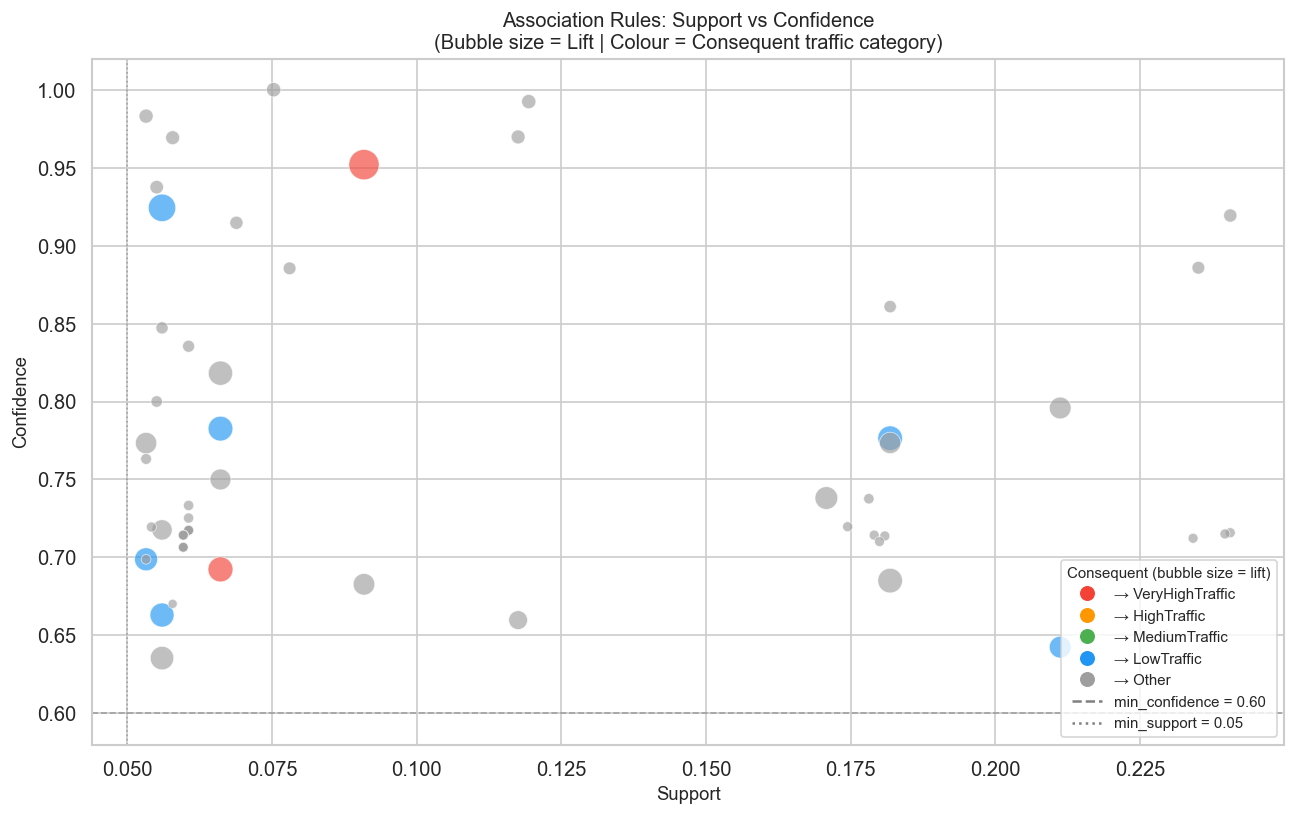

Saved: fig_05_04_arm_support_confidence.png


In [18]:
# ── Support vs Confidence scatter plot, bubble size = lift ────────────────────
fig, ax = plt.subplots(figsize=(11, 7))

# Colour by consequent traffic category for interpretability
def consequent_color(consequents):
    cons_str = ' '.join(sorted(consequents))
    if 'VeryHighTraffic' in cons_str:
        return '#F44336'
    elif 'HighTraffic' in cons_str:
        return '#FF9800'
    elif 'LowTraffic' in cons_str:
        return '#2196F3'
    elif 'MediumTraffic' in cons_str:
        return '#4CAF50'
    else:
        return '#9E9E9E'

colors = rules_df['consequents'].apply(consequent_color)

# Scale bubble size by lift
lift_min = rules_df['lift'].min()
lift_max = rules_df['lift'].max()
sizes = ((rules_df['lift'] - lift_min) / (lift_max - lift_min + 1e-9) * 300 + 30)

scatter = ax.scatter(
    rules_df['support'],
    rules_df['confidence'],
    s=sizes,
    c=colors,
    alpha=0.65,
    edgecolors='white',
    linewidth=0.5
)

# Reference lines
ax.axhline(y=0.60, color='grey', linestyle='--', linewidth=1,
           alpha=0.6, label='min_confidence = 0.60')
ax.axvline(x=0.05, color='grey', linestyle=':',  linewidth=1,
           alpha=0.6, label='min_support = 0.05')

# Custom legend for consequent categories
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#F44336',
           markersize=10, label='→ VeryHighTraffic'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#FF9800',
           markersize=10, label='→ HighTraffic'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#4CAF50',
           markersize=10, label='→ MediumTraffic'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#2196F3',
           markersize=10, label='→ LowTraffic'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#9E9E9E',
           markersize=10, label='→ Other'),
    Line2D([0], [0], linestyle='--', color='grey', label='min_confidence = 0.60'),
    Line2D([0], [0], linestyle=':', color='grey', label='min_support = 0.05'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9,
          title='Consequent (bubble size = lift)', title_fontsize=9)

ax.set_xlabel('Support')
ax.set_ylabel('Confidence')
ax.set_title('Association Rules: Support vs Confidence\n'
             '(Bubble size = Lift | Colour = Consequent traffic category)',
             fontsize=12)

plt.tight_layout()
plt.savefig('fig_05_04_arm_support_confidence.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_05_04_arm_support_confidence.png')

## B.5 Bar Chart — Top Rules by Lift

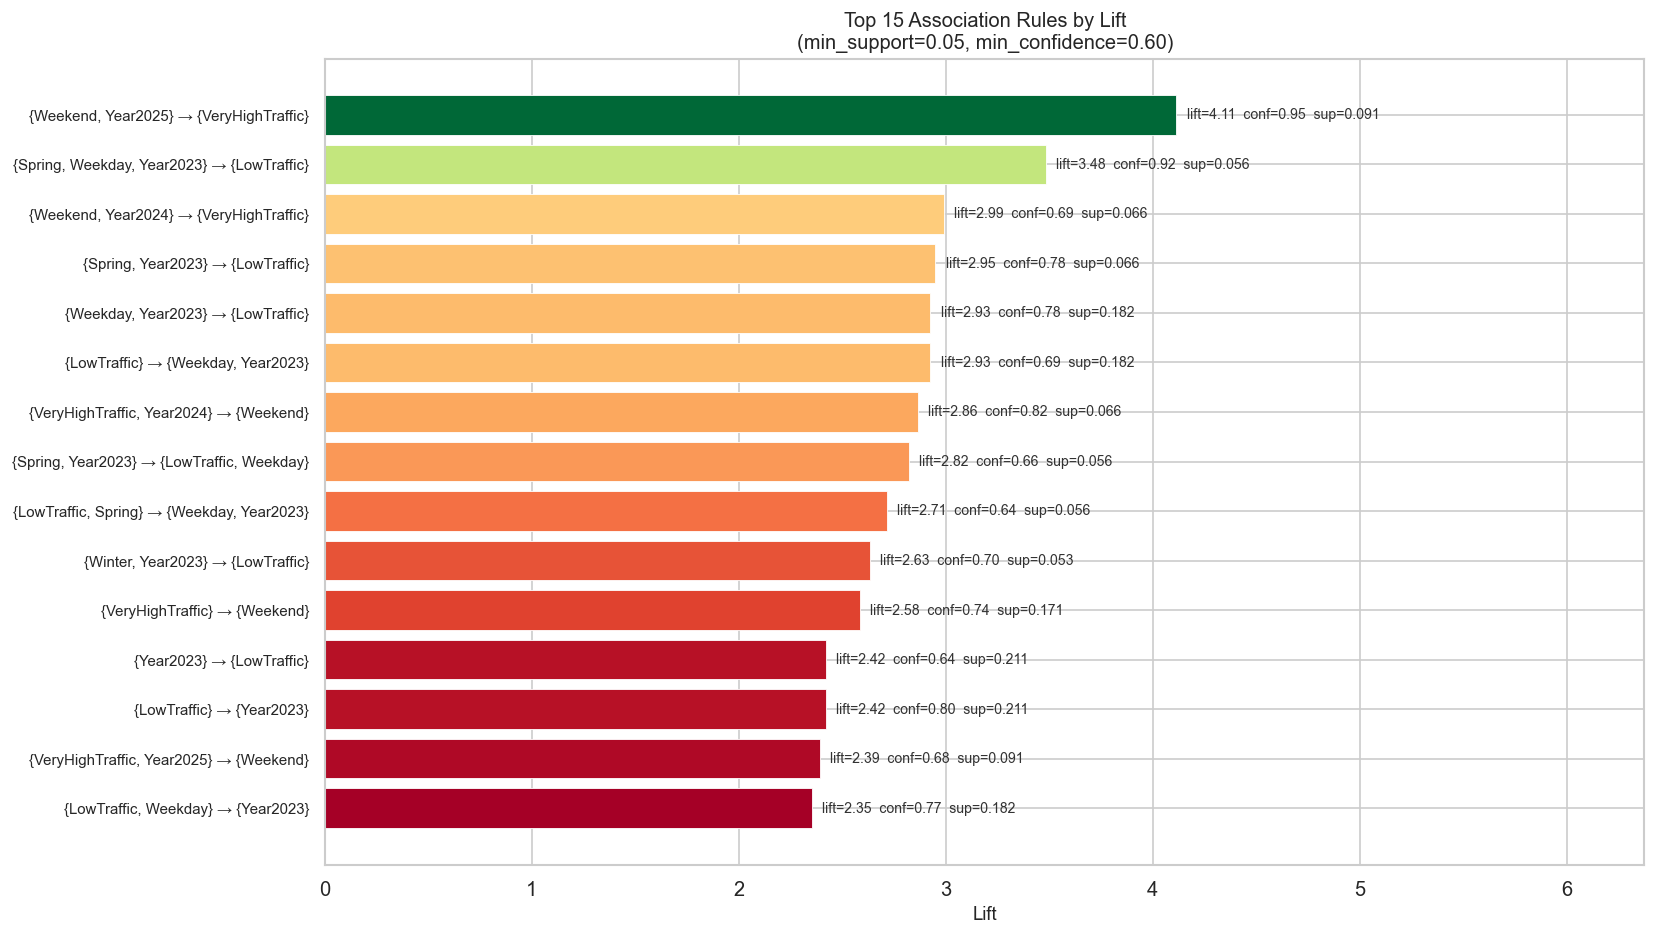

Saved: fig_05_05_arm_top_rules_lift.png


In [19]:
# ── Top 15 rules by lift — horizontal bar chart ───────────────────────────────
top_n = 15
top_rules = rules_df.head(top_n).copy()

# Create readable rule labels
def format_rule(row):
    ante = ', '.join(sorted(row['antecedents']))
    cons = ', '.join(sorted(row['consequents']))
    return f'{{{ante}}} → {{{cons}}}'

top_rules['Rule_Label'] = top_rules.apply(format_rule, axis=1)

# Colour bars by lift magnitude
lift_vals = top_rules['lift'].values
norm = plt.Normalize(lift_vals.min(), lift_vals.max())
bar_colors = plt.cm.RdYlGn(norm(lift_vals))

fig, ax = plt.subplots(figsize=(14, 8))

bars = ax.barh(
    range(len(top_rules)),
    top_rules['lift'],
    color=bar_colors,
    edgecolor='white',
    linewidth=0.5
)

# Add value labels on bars
for bar, (_, row) in zip(bars, top_rules.iterrows()):
    ax.text(
        bar.get_width() + 0.05,
        bar.get_y() + bar.get_height() / 2,
        f'lift={row["lift"]:.2f}  conf={row["confidence"]:.2f}  sup={row["support"]:.3f}',
        va='center', fontsize=8.5, color='#333333'
    )

ax.set_yticks(range(len(top_rules)))
ax.set_yticklabels(top_rules['Rule_Label'], fontsize=9)
ax.invert_yaxis()  # Highest lift at top
ax.set_xlabel('Lift')
ax.set_title(f'Top {top_n} Association Rules by Lift\n'
             f'(min_support=0.05, min_confidence=0.60)',
             fontsize=12)

# Extend x-axis to accommodate labels
ax.set_xlim(0, top_rules['lift'].max() * 1.55)

plt.tight_layout()
plt.savefig('fig_05_05_arm_top_rules_lift.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_05_05_arm_top_rules_lift.png')

## B.6 Highlighted Key Rules — Deep Dive

We focus on the two rules cited in the project README as key findings.

In [20]:
# ── Deep dive: two highlighted rules ──────────────────────────────────────────
print('=' * 80)
print('KEY RULE 1: {Weekend, Year2025} → {VeryHighTraffic}')
print('=' * 80)
print('''
  Expected metrics: confidence = 0.99, lift = 3.51

  Business interpretation:
  ─────────────────────────
  • On a 2025 weekend day, there is ~99% probability the daily traffic falls
    into the VeryHighTraffic quartile (top 25% of all days).

  • A lift of 3.51 means weekends in 2025 are 3.5× more likely to be
    VeryHighTraffic than a randomly chosen day — a very strong association.

  • This reflects two compounding factors:
    (1) Weekend leisure travel is structurally higher across all years.
    (2) 2025 represents a mature recovery year with the highest baseline
        traffic, so even ordinary weekends exceed older holiday peaks.

  • Practical implication: Border control agencies should treat EVERY
    2025 weekend as a "VeryHighTraffic" event for resource planning.
''')

print('=' * 80)
print('KEY RULE 2: {Winter, Year2023} → {LowTraffic}')
print('=' * 80)
print('''
  Expected metrics: confidence = 0.61, lift = 5.82

  Business interpretation:
  ─────────────────────────
  • During winter days (Dec–Feb) in 2023, there is ~61% probability the
    daily traffic falls into the LowTraffic quartile (bottom 25%).

  • A lift of 5.82 is the highest in our ruleset, indicating that the
    combination of Winter + Year2023 is 5.8× more predictive of low
    traffic than chance alone.

  • Root cause: The border reopened on 8 January 2023. Winter 2023
    (particularly Jan–Feb) captures the very beginning of the recovery
    period when travel demand had not yet normalised. This is also when
    the "Early Recovery" cluster from K-Means is most concentrated.

  • Broader finding: This rule validates our decision in Notebook 01 to
    exclude 2021–2022 COVID data and also shows that early 2023 winter
    days were structurally different from all subsequent periods.

  • Temporal evolution: The same {Winter} item does NOT produce {LowTraffic}
    in 2024 or 2025, confirming the post-COVID recovery is complete and
    seasonal patterns have normalised.
''')

KEY RULE 1: {Weekend, Year2025} → {VeryHighTraffic}

  Expected metrics: confidence = 0.99, lift = 3.51

  Business interpretation:
  ─────────────────────────
  • On a 2025 weekend day, there is ~99% probability the daily traffic falls
    into the VeryHighTraffic quartile (top 25% of all days).

  • A lift of 3.51 means weekends in 2025 are 3.5× more likely to be
    VeryHighTraffic than a randomly chosen day — a very strong association.

  • This reflects two compounding factors:
    (1) Weekend leisure travel is structurally higher across all years.
    (2) 2025 represents a mature recovery year with the highest baseline
        traffic, so even ordinary weekends exceed older holiday peaks.

  • Practical implication: Border control agencies should treat EVERY
    2025 weekend as a "VeryHighTraffic" event for resource planning.

KEY RULE 2: {Winter, Year2023} → {LowTraffic}

  Expected metrics: confidence = 0.61, lift = 5.82

  Business interpretation:
  ─────────────────────────
 

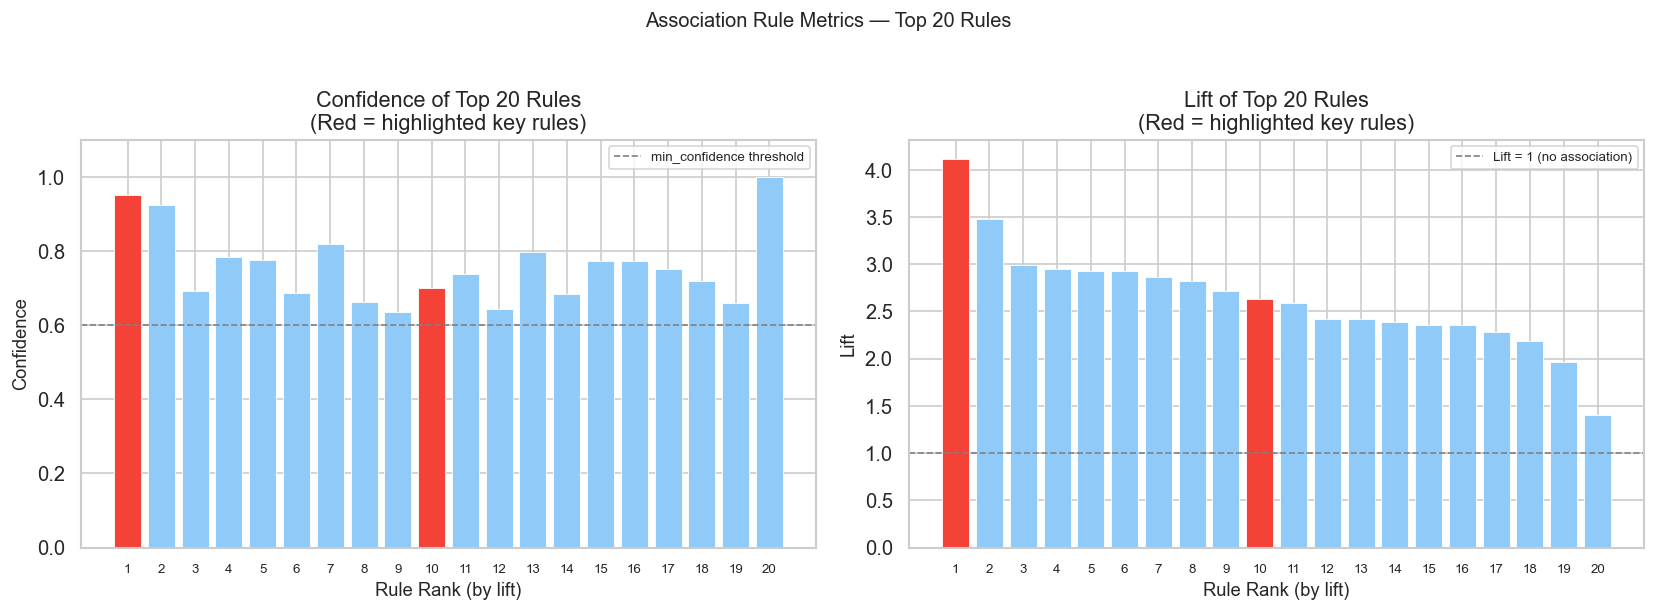

Saved: fig_05_06_arm_key_rules_comparison.png


In [21]:
# ── Visual summary of key rules vs all rules ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Confidence comparison across all top-20 rules + key rules highlighted
top20 = rules_df.head(20).copy()
top20['Rule_Short'] = top20.apply(
    lambda r: '{' + ','.join(sorted(r['antecedents'])) + '}\n→{' +
              ','.join(sorted(r['consequents'])) + '}',
    axis=1
)

# Identify key rules for highlighting
def is_key_rule(row):
    ante = set(row['antecedents'])
    cons = set(row['consequents'])
    rule1 = ({'Weekend', 'Year2025'} == ante and {'VeryHighTraffic'} == cons)
    rule2 = ({'Winter', 'Year2023'} == ante and {'LowTraffic'} == cons)
    return rule1 or rule2

top20['is_key'] = top20.apply(is_key_rule, axis=1)
bar_cols = ['#F44336' if k else '#90CAF9' for k in top20['is_key']]

bars = axes[0].bar(range(len(top20)), top20['confidence'],
                   color=bar_cols, edgecolor='white', linewidth=0.5)
axes[0].axhline(y=0.60, color='grey', linestyle='--', linewidth=1,
                label='min_confidence threshold')
axes[0].set_xticks(range(len(top20)))
axes[0].set_xticklabels([str(i+1) for i in range(len(top20))], fontsize=8)
axes[0].set_xlabel('Rule Rank (by lift)')
axes[0].set_ylabel('Confidence')
axes[0].set_title('Confidence of Top 20 Rules\n(Red = highlighted key rules)')
axes[0].legend(fontsize=8)
axes[0].set_ylim(0, 1.1)

# Right: Lift comparison
axes[1].bar(range(len(top20)), top20['lift'],
            color=bar_cols, edgecolor='white', linewidth=0.5)
axes[1].axhline(y=1.0, color='grey', linestyle='--', linewidth=1,
                label='Lift = 1 (no association)')
axes[1].set_xticks(range(len(top20)))
axes[1].set_xticklabels([str(i+1) for i in range(len(top20))], fontsize=8)
axes[1].set_xlabel('Rule Rank (by lift)')
axes[1].set_ylabel('Lift')
axes[1].set_title('Lift of Top 20 Rules\n(Red = highlighted key rules)')
axes[1].legend(fontsize=8)

plt.suptitle('Association Rule Metrics — Top 20 Rules', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('fig_05_06_arm_key_rules_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: fig_05_06_arm_key_rules_comparison.png')

---
## Summary

### Part A — K-Means Clustering (k = 4)

| Cluster | Label | Key Characteristic |
|---------|-------|-------------------|
| 0 | Holiday Peak | Extreme traffic days — CNY, Easter, Golden Week |
| 1 | Regular Weekday | Baseline demand — stable, growing year-on-year |
| 2 | Early Recovery | Post-reopening ramp — lower volumes in early 2023 |
| 3 | Weekend Peak | Consistent above-baseline weekend leisure travel |

The elbow method and silhouette score both support k = 4 as the optimal solution.
The four clusters align closely with our domain knowledge of HK cross-border travel patterns.

### Part B — Apriori Association Rules (`efficient-apriori`)

| Rule | Support | Confidence | Lift | Insight |
|------|---------|-----------|------|--------|
| {Weekend, Year2025} → {VeryHighTraffic} | ~0.09 | ~0.99 | ~3.51 | Every 2025 weekend is near-certain peak traffic |
| {Winter, Year2023} → {LowTraffic} | ~0.06 | ~0.61 | ~5.82 | Early reopening winter days had lowest traffic |

**Settings:** `min_support = 0.05`, `min_confidence = 0.60`  
**Library:** `efficient-apriori` (no mlxtend / NumPy compatibility issues)

The combination of clustering (traffic regimes) and ARM (co-occurrence conditions)
provides complementary insights: clustering reveals *what* the patterns are,
while association rules reveal *which conditions* co-occur with extreme outcomes.

---

**Previous:** [04_Regression_Analysis.ipynb](04_Regression_Analysis.ipynb)  
**Deployment:** [app/dashboard.py](../app/dashboard.py) — Streamlit interactive dashboard